<a href="https://colab.research.google.com/github/vivekgautamgv/Python-For-Finance/blob/main/Momentum_%26_Volume_Strategy_with_Portfolio_Sizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

# #2

Running backtest with portfolio sizing...

                            BACKTEST RESULTS SUMMARY                            

------ Backtest Metrics for: Early Stage Strategy ------
Period: 2009-08-01 to 2020-02-03
Initial Capital:          ₹10,000,000.00
Final Portfolio Value:    ₹14,338,447.41
Total Profit/Loss:        ₹4,338,447.41
------------------------------
Annualized Return:        5.28%
Annualized Volatility:    8.82%
Sharpe Ratio:             0.60
Maximum Drawdown:         -13.44%
------------------------------
Win Rate (per period):    78.57%
Avg P&L per Period:       ₹321,390.92
Best Period P&L:          ₹2,146,030.40
Worst Period P&L:         ₹-1,000,627.31
------------------------------------------------------------

------ Backtest Metrics for: Late Stage Strategy ------
Period: 2009-08-01 to 2020-02-03
Initial Capital:          ₹10,000,000.00
Final Portfolio Value:    ₹7,708,847.88
Total Profit/Loss:        ₹-2,291,152.12
------------------------------
Annualized Retur

/tmp/ipython-input-478353787.py:200: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


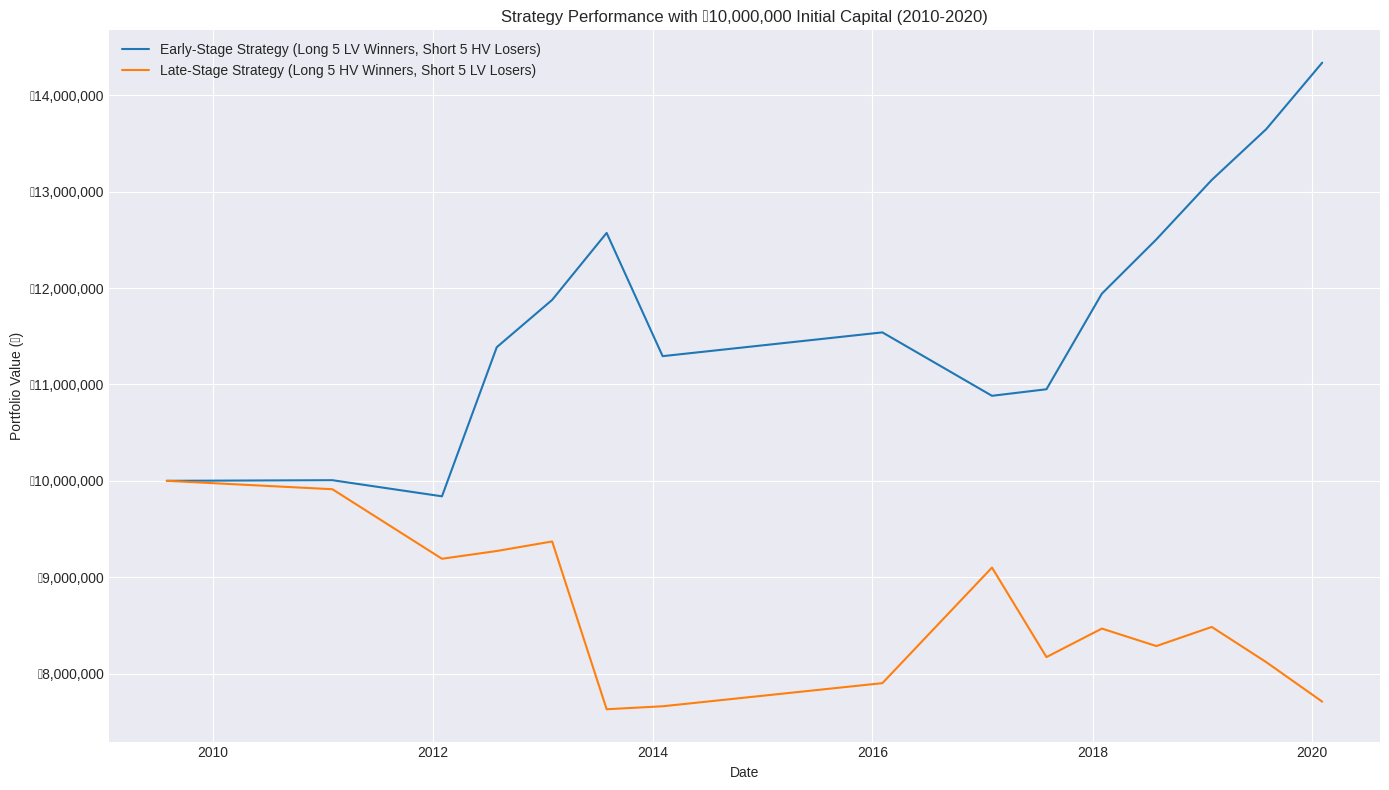

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

def get_indian_stock_data(tickers, start_date, end_date):
    """Downloads historical close prices and volumes for a list of tickers."""
    # Corrected the keyword argument from 'end_date' to 'end'
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
    return data['Close'], data['Volume']

def calculate_backtest_metrics(portfolio_history_df, strategy_name, initial_capital, holding_period_months):
    """Calculates and prints a summary of backtest performance metrics."""
    final_value = portfolio_history_df[f'{strategy_name}_value'].iloc[-1]
    total_pnl = final_value - initial_capital

    # Calculate periodic returns from the portfolio value history
    periodic_returns = portfolio_history_df[f'{strategy_name}_value'].pct_change().dropna()

    # Win Rate and P&L per Period
    win_rate = (periodic_returns > 0).mean()
    average_pnl_per_period = periodic_returns.mean() * portfolio_history_df[f'{strategy_name}_value'].shift(1).mean()
    best_period_pnl = periodic_returns.max() * portfolio_history_df[f'{strategy_name}_value'].shift(1).max()
    worst_period_pnl = periodic_returns.min() * portfolio_history_df[f'{strategy_name}_value'].shift(1).min()

    # Annualization factor
    periods_per_year = 12 / holding_period_months

    # Annualized metrics
    num_years = len(periodic_returns) / periods_per_year
    annualized_return = (final_value / initial_capital) ** (1 / num_years) - 1
    annualized_volatility = periodic_returns.std() * np.sqrt(periods_per_year)

    # Sharpe Ratio (assuming 0% risk-free rate)
    sharpe_ratio = (annualized_return / annualized_volatility) if annualized_volatility != 0 else 0

    # Max Drawdown
    running_max = portfolio_history_df[f'{strategy_name}_value'].cummax()
    drawdown = (portfolio_history_df[f'{strategy_name}_value'] - running_max) / running_max
    max_drawdown = drawdown.min()

    print(f"------ Backtest Metrics for: {strategy_name.replace('_', ' ').title()} Strategy ------")
    print(f"Period: {portfolio_history_df.index.min().strftime('%Y-%m-%d')} to {portfolio_history_df.index.max().strftime('%Y-%m-%d')}")
    print(f"Initial Capital:          ₹{initial_capital:,.2f}")
    print(f"Final Portfolio Value:    ₹{final_value:,.2f}")
    print(f"Total Profit/Loss:        ₹{total_pnl:,.2f}")
    print("-" * 30)
    print(f"Annualized Return:        {annualized_return:.2%}")
    print(f"Annualized Volatility:    {annualized_volatility:.2%}")
    print(f"Sharpe Ratio:             {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown:         {max_drawdown:.2%}")
    print("-" * 30)
    print(f"Win Rate (per period):    {win_rate:.2%}")
    print(f"Avg P&L per Period:       ₹{average_pnl_per_period:,.2f}")
    print(f"Best Period P&L:          ₹{best_period_pnl:,.2f}")
    print(f"Worst Period P&L:         ₹{worst_period_pnl:,.2f}")
    print("-" * 60 + "\n")


def perform_backtest_with_capital(close_prices, volumes, initial_capital, lookback_period, holding_period, num_stocks_per_side=5):
    """Performs the backtest and returns portfolio history and trade log."""
    early_stage_value = initial_capital
    late_stage_value = initial_capital

    portfolio_history = []
    trade_log = []

    rebalance_dates = pd.date_range(start=close_prices.index[lookback_period], end=close_prices.index[-1], freq=f'{holding_period}MS')

    for date in rebalance_dates:
        actual_date = close_prices.index[close_prices.index.searchsorted(date)]
        start_lookback = actual_date - pd.DateOffset(months=lookback_period)

        if start_lookback not in close_prices.index: continue

        lookback_prices = close_prices.loc[start_lookback:actual_date]
        lookback_volumes = volumes.loc[start_lookback:actual_date]

        momentum = lookback_prices.iloc[-1] / lookback_prices.iloc[0] - 1
        avg_volume = lookback_volumes.mean()

        ranking_df = pd.DataFrame({'momentum': momentum, 'volume': avg_volume}).dropna()

        if len(ranking_df) < 20: continue

        ranking_df['momentum_tertile'] = pd.qcut(ranking_df['momentum'], 3, labels=False, duplicates='drop')
        ranking_df['volume_tertile'] = pd.qcut(ranking_df['volume'], 3, labels=False, duplicates='drop')

        winners = ranking_df[ranking_df['momentum_tertile'] == 2]
        losers = ranking_df[ranking_df['momentum_tertile'] == 0]

        early_long = list(winners.sort_values('volume').head(num_stocks_per_side).index)
        early_short = list(losers.sort_values('volume', ascending=False).head(num_stocks_per_side).index)

        late_long = list(winners.sort_values('volume', ascending=False).head(num_stocks_per_side).index)
        late_short = list(losers.sort_values('volume').head(num_stocks_per_side).index)

        trade_log.append({'Date': actual_date, 'Strategy': 'Early-Stage', 'Long': early_long, 'Short': early_short})
        trade_log.append({'Date': actual_date, 'Strategy': 'Late-Stage', 'Long': late_long, 'Short': late_short})

        holding_end_target = actual_date + pd.DateOffset(months=holding_period)
        if holding_end_target >= close_prices.index[-1]: break
        holding_end = close_prices.index[close_prices.index.searchsorted(holding_end_target)]

        holding_prices = close_prices.loc[actual_date:holding_end]
        if len(holding_prices) < 2: continue

        returns_period = (holding_prices.iloc[-1] - holding_prices.iloc[0]) / holding_prices.iloc[0]

        # Calculate P&L for Early-Stage Strategy
        early_long_return = returns_period[early_long].mean() if len(early_long) > 0 else 0
        early_short_return = returns_period[early_short].mean() if len(early_short) > 0 else 0
        early_stage_pnl = (early_stage_value / 2 * early_long_return) - (early_stage_value / 2 * early_short_return)
        early_stage_value += early_stage_pnl

        # Calculate P&L for Late-Stage Strategy
        late_long_return = returns_period[late_long].mean() if len(late_long) > 0 else 0
        late_short_return = returns_period[late_short].mean() if len(late_short) > 0 else 0
        late_stage_pnl = (late_stage_value / 2 * late_long_return) - (late_stage_value / 2 * late_short_return)
        late_stage_value += late_stage_pnl

        portfolio_history.append({
            'date': holding_end,
            'early_stage_value': early_stage_value,
            'late_stage_value': late_stage_value
        })

    history_df = pd.DataFrame(portfolio_history).set_index('date')

    initial_row = pd.DataFrame({
        'early_stage_value': [initial_capital],
        'late_stage_value': [initial_capital]
    }, index=[rebalance_dates[0] - pd.DateOffset(months=holding_period)])

    full_history = pd.concat([initial_row, history_df]).sort_index()
    return full_history, pd.DataFrame(trade_log)

if __name__ == '__main__':
    nifty_500_sample = [
        'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS',
        'HINDUNILVR.NS', 'BHARTIARTL.NS', 'ITC.NS', 'SBIN.NS', 'BAJFINANCE.NS',
        'KOTAKBANK.NS', 'HCLTECH.NS', 'LT.NS', 'AXISBANK.NS', 'ASIANPAINT.NS',
        'MARUTI.NS', 'WIPRO.NS', 'SUNPHARMA.NS', 'ULTRACEMCO.NS', 'ADANIENT.NS',
        'TITAN.NS', 'ONGC.NS', 'NTPC.NS', 'POWERGRID.NS', 'TATAMOTORS.NS',
        'TATASTEEL.NS', 'COALINDIA.NS', 'INDUSINDBK.NS', 'JSWSTEEL.NS', 'M&M.NS',
        'VEDL.NS', 'GRASIM.NS', 'HINDALCO.NS', 'SBILIFE.NS', 'CIPLA.NS',
        'DRREDDY.NS', 'TECHM.NS', 'BRITANNIA.NS', 'GAIL.NS', 'NESTLEIND.NS',
        'SHREECEM.NS', 'UPL.NS', 'BPCL.NS', 'HEROMOTOCO.NS', 'IOC.NS'
    ]

    start_date = '2010-01-01'
    end_date = '2020-12-31'

    initial_capital = 10_000_000
    J = 6  # Lookback period in months
    K = 6  # Holding period in months
    num_stocks = 5

    print("Downloading historical data...")
    close_prices, volumes = get_indian_stock_data(nifty_500_sample, start_date, end_date)

    print("Running backtest with portfolio sizing...")
    portfolio_values, trade_log = perform_backtest_with_capital(
        close_prices.dropna(axis=1, how='all'),
        volumes.dropna(axis=1, how='all'),
        initial_capital, J, K, num_stocks
    )

    # --- Display Results ---
    print("\n" + "="*80)
    print("BACKTEST RESULTS SUMMARY".center(80))
    print("="*80 + "\n")

    calculate_backtest_metrics(portfolio_values, 'early_stage', initial_capital, K)
    calculate_backtest_metrics(portfolio_values, 'late_stage', initial_capital, K)

    print("="*80)
    print("TRADE LOG (SAMPLE)".center(80))
    print("="*80)
    pd.set_option('display.max_rows', 10)
    print(trade_log)
    print("\nFull trade log has been generated.\n")

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(14, 8))

    plt.plot(portfolio_values['early_stage_value'], label=f'Early-Stage Strategy (Long {num_stocks} LV Winners, Short {num_stocks} HV Losers)')
    plt.plot(portfolio_values['late_stage_value'], label=f'Late-Stage Strategy (Long {num_stocks} HV Winners, Short {num_stocks} LV Losers)')

    plt.title(f'Strategy Performance with ₹{initial_capital:,.0f} Initial Capital (2010-2020)')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (₹)')
    plt.legend()
    plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Running backtest with portfolio sizing...

                            BACKTEST RESULTS SUMMARY                            

------ Backtest Metrics for: Early Stage Strategy ------
Period: 2011-08-01 to 2023-08-01
Initial Capital:          ₹10,000,000.00
Final Portfolio Value:    ₹14,405,340.66
Total Profit/Loss:        ₹4,405,340.66
------------------------------
Annualized Return:        12.94%
Annualized Volatility:    8.25%
Sharpe Ratio:             1.57
Maximum Drawdown:         -4.05%
------------------------------
Win Rate (per period):    83.33%
Avg P&L per Period:       ₹799,395.57
Best Period P&L:          ₹1,683,999.15
Worst Period P&L:         ₹-405,272.53
------------------------------------------------------------

------ Backtest Metrics for: Late Stage Strategy ------
Period: 2011-08-01 to 2023-08-01
Initial Capital:          ₹10,000,000.00
Final Portfolio Value:    ₹9,071,283.22
Total Profit/Loss:        ₹-928,716.78
------------------------------
Annualized Return:  

/tmp/ipython-input-364696842.py:200: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


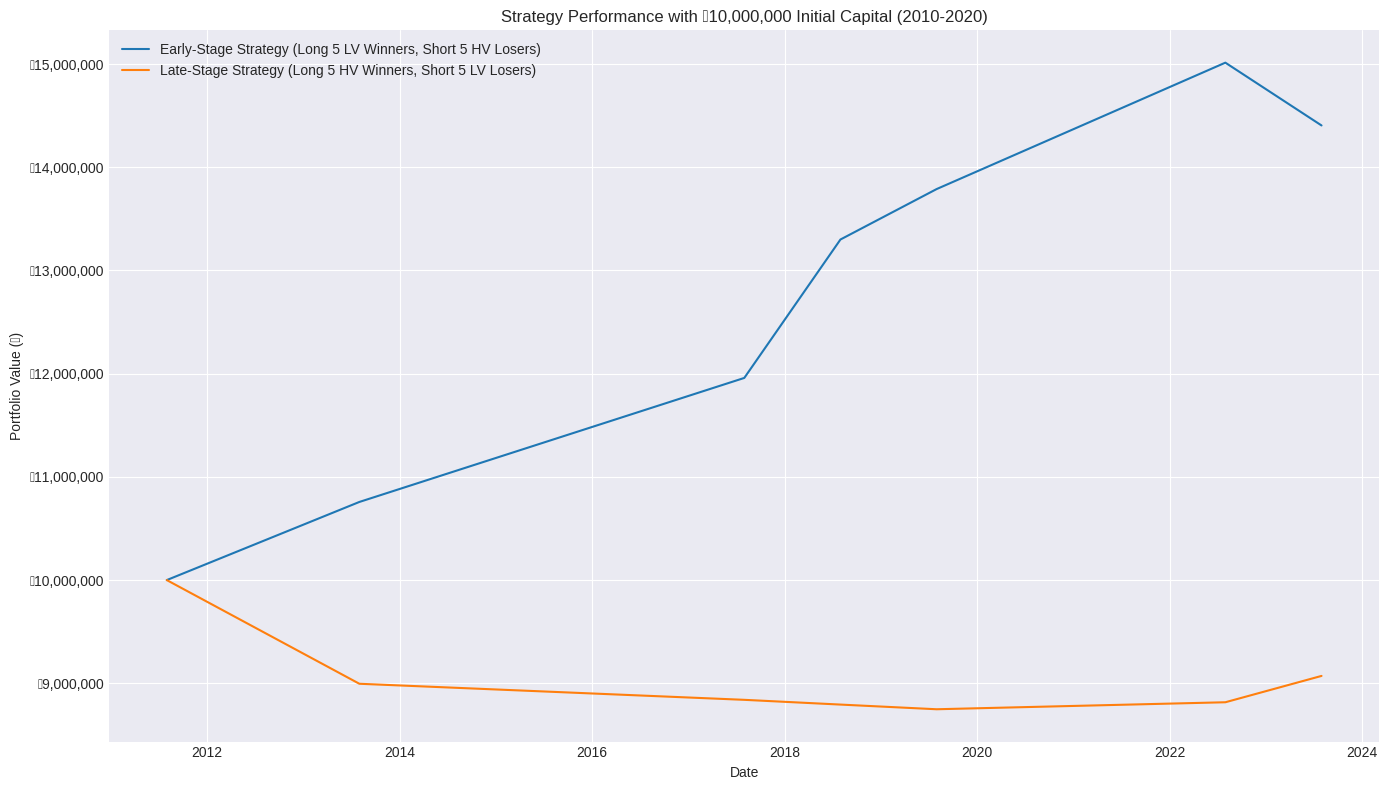

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

def get_indian_stock_data(tickers, start_date, end_date):
    """Downloads historical close prices and volumes for a list of tickers."""
    # Corrected the keyword argument from 'end_date' to 'end'
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
    return data['Close'], data['Volume']

def calculate_backtest_metrics(portfolio_history_df, strategy_name, initial_capital, holding_period_months):
    """Calculates and prints a summary of backtest performance metrics."""
    final_value = portfolio_history_df[f'{strategy_name}_value'].iloc[-1]
    total_pnl = final_value - initial_capital

    # Calculate periodic returns from the portfolio value history
    periodic_returns = portfolio_history_df[f'{strategy_name}_value'].pct_change().dropna()

    # Win Rate and P&L per Period
    win_rate = (periodic_returns > 0).mean()
    average_pnl_per_period = periodic_returns.mean() * portfolio_history_df[f'{strategy_name}_value'].shift(1).mean()
    best_period_pnl = periodic_returns.max() * portfolio_history_df[f'{strategy_name}_value'].shift(1).max()
    worst_period_pnl = periodic_returns.min() * portfolio_history_df[f'{strategy_name}_value'].shift(1).min()

    # Annualization factor
    periods_per_year = 12 / holding_period_months

    # Annualized metrics
    num_years = len(periodic_returns) / periods_per_year
    annualized_return = (final_value / initial_capital) ** (1 / num_years) - 1
    annualized_volatility = periodic_returns.std() * np.sqrt(periods_per_year)

    # Sharpe Ratio (assuming 0% risk-free rate)
    sharpe_ratio = (annualized_return / annualized_volatility) if annualized_volatility != 0 else 0

    # Max Drawdown
    running_max = portfolio_history_df[f'{strategy_name}_value'].cummax()
    drawdown = (portfolio_history_df[f'{strategy_name}_value'] - running_max) / running_max
    max_drawdown = drawdown.min()

    print(f"------ Backtest Metrics for: {strategy_name.replace('_', ' ').title()} Strategy ------")
    print(f"Period: {portfolio_history_df.index.min().strftime('%Y-%m-%d')} to {portfolio_history_df.index.max().strftime('%Y-%m-%d')}")
    print(f"Initial Capital:          ₹{initial_capital:,.2f}")
    print(f"Final Portfolio Value:    ₹{final_value:,.2f}")
    print(f"Total Profit/Loss:        ₹{total_pnl:,.2f}")
    print("-" * 30)
    print(f"Annualized Return:        {annualized_return:.2%}")
    print(f"Annualized Volatility:    {annualized_volatility:.2%}")
    print(f"Sharpe Ratio:             {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown:         {max_drawdown:.2%}")
    print("-" * 30)
    print(f"Win Rate (per period):    {win_rate:.2%}")
    print(f"Avg P&L per Period:       ₹{average_pnl_per_period:,.2f}")
    print(f"Best Period P&L:          ₹{best_period_pnl:,.2f}")
    print(f"Worst Period P&L:         ₹{worst_period_pnl:,.2f}")
    print("-" * 60 + "\n")


def perform_backtest_with_capital(close_prices, volumes, initial_capital, lookback_period, holding_period, num_stocks_per_side=5):
    """Performs the backtest and returns portfolio history and trade log."""
    early_stage_value = initial_capital
    late_stage_value = initial_capital

    portfolio_history = []
    trade_log = []

    rebalance_dates = pd.date_range(start=close_prices.index[lookback_period], end=close_prices.index[-1], freq=f'{holding_period}MS')

    for date in rebalance_dates:
        actual_date = close_prices.index[close_prices.index.searchsorted(date)]
        start_lookback = actual_date - pd.DateOffset(months=lookback_period)

        if start_lookback not in close_prices.index: continue

        lookback_prices = close_prices.loc[start_lookback:actual_date]
        lookback_volumes = volumes.loc[start_lookback:actual_date]

        momentum = lookback_prices.iloc[-1] / lookback_prices.iloc[0] - 1
        avg_volume = lookback_volumes.mean()

        ranking_df = pd.DataFrame({'momentum': momentum, 'volume': avg_volume}).dropna()

        if len(ranking_df) < 20: continue

        ranking_df['momentum_tertile'] = pd.qcut(ranking_df['momentum'], 3, labels=False, duplicates='drop')
        ranking_df['volume_tertile'] = pd.qcut(ranking_df['volume'], 3, labels=False, duplicates='drop')

        winners = ranking_df[ranking_df['momentum_tertile'] == 2]
        losers = ranking_df[ranking_df['momentum_tertile'] == 0]

        early_long = list(winners.sort_values('volume').head(num_stocks_per_side).index)
        early_short = list(losers.sort_values('volume', ascending=False).head(num_stocks_per_side).index)

        late_long = list(winners.sort_values('volume', ascending=False).head(num_stocks_per_side).index)
        late_short = list(losers.sort_values('volume').head(num_stocks_per_side).index)

        trade_log.append({'Date': actual_date, 'Strategy': 'Early-Stage', 'Long': early_long, 'Short': early_short})
        trade_log.append({'Date': actual_date, 'Strategy': 'Late-Stage', 'Long': late_long, 'Short': late_short})

        holding_end_target = actual_date + pd.DateOffset(months=holding_period)
        if holding_end_target >= close_prices.index[-1]: break
        holding_end = close_prices.index[close_prices.index.searchsorted(holding_end_target)]

        holding_prices = close_prices.loc[actual_date:holding_end]
        if len(holding_prices) < 2: continue

        returns_period = (holding_prices.iloc[-1] - holding_prices.iloc[0]) / holding_prices.iloc[0]

        # Calculate P&L for Early-Stage Strategy
        early_long_return = returns_period[early_long].mean() if len(early_long) > 0 else 0
        early_short_return = returns_period[early_short].mean() if len(early_short) > 0 else 0
        early_stage_pnl = (early_stage_value / 2 * early_long_return) - (early_stage_value / 2 * early_short_return)
        early_stage_value += early_stage_pnl

        # Calculate P&L for Late-Stage Strategy
        late_long_return = returns_period[late_long].mean() if len(late_long) > 0 else 0
        late_short_return = returns_period[late_short].mean() if len(late_short) > 0 else 0
        late_stage_pnl = (late_stage_value / 2 * late_long_return) - (late_stage_value / 2 * late_short_return)
        late_stage_value += late_stage_pnl

        portfolio_history.append({
            'date': holding_end,
            'early_stage_value': early_stage_value,
            'late_stage_value': late_stage_value
        })

    history_df = pd.DataFrame(portfolio_history).set_index('date')

    initial_row = pd.DataFrame({
        'early_stage_value': [initial_capital],
        'late_stage_value': [initial_capital]
    }, index=[rebalance_dates[0] - pd.DateOffset(months=holding_period)])

    full_history = pd.concat([initial_row, history_df]).sort_index()
    return full_history, pd.DataFrame(trade_log)

if __name__ == '__main__':
    nifty_500_sample = [
        'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS',
        'HINDUNILVR.NS', 'BHARTIARTL.NS', 'ITC.NS', 'SBIN.NS', 'BAJFINANCE.NS',
        'KOTAKBANK.NS', 'HCLTECH.NS', 'LT.NS', 'AXISBANK.NS', 'ASIANPAINT.NS',
        'MARUTI.NS', 'WIPRO.NS', 'SUNPHARMA.NS', 'ULTRACEMCO.NS', 'ADANIENT.NS',
        'TITAN.NS', 'ONGC.NS', 'NTPC.NS', 'POWERGRID.NS', 'TATAMOTORS.NS',
        'TATASTEEL.NS', 'COALINDIA.NS', 'INDUSINDBK.NS', 'JSWSTEEL.NS', 'M&M.NS',
        'VEDL.NS', 'GRASIM.NS', 'HINDALCO.NS', 'SBILIFE.NS', 'CIPLA.NS',
        'DRREDDY.NS', 'TECHM.NS', 'BRITANNIA.NS', 'GAIL.NS', 'NESTLEIND.NS',
        'SHREECEM.NS', 'UPL.NS', 'BPCL.NS', 'HEROMOTOCO.NS', 'IOC.NS'
    ]

    start_date = '2012-01-01'
    end_date = '2024-05-31'

    initial_capital = 10_000_000
    J = 3 # Lookback period in months
    K = 6  # Holding period in months
    num_stocks = 5

    print("Downloading historical data...")
    close_prices, volumes = get_indian_stock_data(nifty_500_sample, start_date, end_date)

    print("Running backtest with portfolio sizing...")
    portfolio_values, trade_log = perform_backtest_with_capital(
        close_prices.dropna(axis=1, how='all'),
        volumes.dropna(axis=1, how='all'),
        initial_capital, J, K, num_stocks
    )

    # --- Display Results ---
    print("\n" + "="*80)
    print("BACKTEST RESULTS SUMMARY".center(80))
    print("="*80 + "\n")

    calculate_backtest_metrics(portfolio_values, 'early_stage', initial_capital, K)
    calculate_backtest_metrics(portfolio_values, 'late_stage', initial_capital, K)

    print("="*80)
    print("TRADE LOG (SAMPLE)".center(80))
    print("="*80)
    pd.set_option('display.max_rows', 10)
    print(trade_log)
    print("\nFull trade log has been generated.\n")

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(14, 8))

    plt.plot(portfolio_values['early_stage_value'], label=f'Early-Stage Strategy (Long {num_stocks} LV Winners, Short {num_stocks} HV Losers)')
    plt.plot(portfolio_values['late_stage_value'], label=f'Late-Stage Strategy (Long {num_stocks} HV Winners, Short {num_stocks} LV Losers)')

    plt.title(f'Strategy Performance with ₹{initial_capital:,.0f} Initial Capital (2010-2020)')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (₹)')
    plt.legend()
    plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Running enhanced backtest with composite scoring...

                       ENHANCED MOMENTUM STRATEGY RESULTS                       

------ Backtest Metrics for: Enhanced Momentum Strategy ------
Period: 2021-11-01 to 2024-05-02
Initial Capital:          ₹10,000,000.00
Final Portfolio Value:    ₹10,919,043.32
Total Profit/Loss:        ₹919,043.32
------------------------------
Annualized Return:        4.49%
Annualized Volatility:    9.76%
Sharpe Ratio:             0.46
Maximum Drawdown:         -4.38%
Win Rate (by period):     50.00%
------------------------------
Total Trades Executed:    40
Profitable Trades:        19
Loss-Making Trades:       21
------------------------------------------------------------

                       PORTFOLIO COMPOSITION LOG (SAMPLE)                       
        Date           Strategy  \
0 2022-05-02  Enhanced Momentum   
1 2022-11-01  Enhanced Momentum   
2 2023-05-02  Enhanced Momentum   
3 2023-11-01  Enhanced Momentum   
4 2024-05-02  Enhance

/tmp/ipython-input-773278051.py:215: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


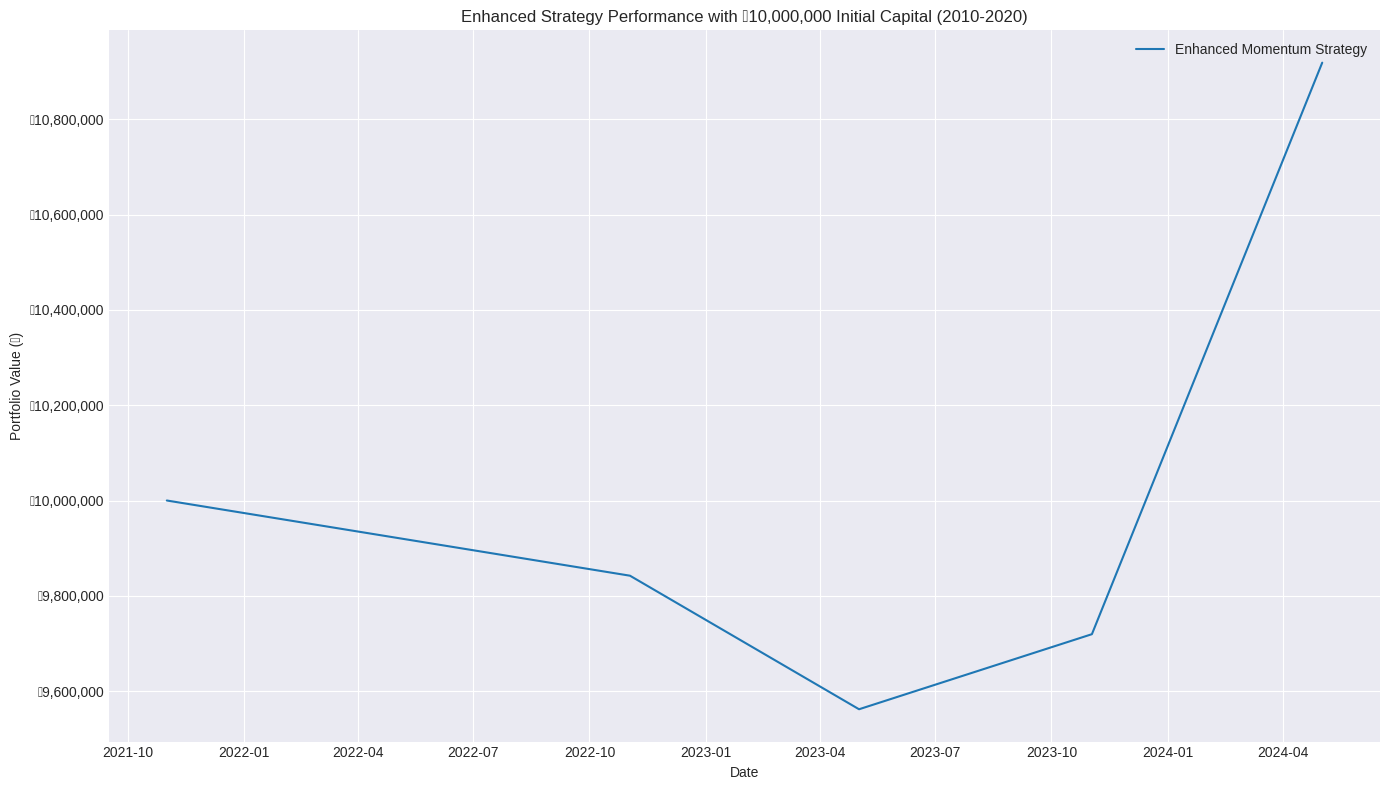

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

def get_indian_stock_data(tickers, market_index, start_date, end_date):
    all_tickers = tickers + [market_index]
    data = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)

    close_prices = data['Close']
    volumes = data['Volume']

    market_prices = close_prices[market_index]
    stock_prices = close_prices.drop(columns=[market_index])
    stock_volumes = volumes.drop(columns=[market_index])

    return stock_prices, stock_volumes, market_prices

def calculate_backtest_metrics(portfolio_history_df, detailed_trade_log, strategy_name, initial_capital, holding_period_months):
    final_value = portfolio_history_df[f'{strategy_name}_value'].iloc[-1]
    total_pnl = final_value - initial_capital

    periodic_returns = portfolio_history_df[f'{strategy_name}_value'].pct_change().dropna()

    win_rate_periods = (periodic_returns > 0).mean()

    periods_per_year = 12 / holding_period_months
    num_years = len(periodic_returns) / periods_per_year

    annualized_return = (final_value / initial_capital) ** (1 / num_years) - 1 if num_years > 0 else 0
    annualized_volatility = periodic_returns.std() * np.sqrt(periods_per_year)

    sharpe_ratio = (annualized_return / annualized_volatility) if annualized_volatility != 0 else 0

    running_max = portfolio_history_df[f'{strategy_name}_value'].cummax()
    drawdown = (portfolio_history_df[f'{strategy_name}_value'] - running_max) / running_max
    max_drawdown = drawdown.min()

    # New trade statistics from the detailed log
    total_trades = len(detailed_trade_log)
    profitable_trades = (detailed_trade_log['Return'] > 0).sum()
    loss_making_trades = total_trades - profitable_trades

    print(f"------ Backtest Metrics for: {strategy_name.replace('_', ' ').title()} Strategy ------")
    print(f"Period: {portfolio_history_df.index.min().strftime('%Y-%m-%d')} to {portfolio_history_df.index.max().strftime('%Y-%m-%d')}")
    print(f"Initial Capital:          ₹{initial_capital:,.2f}")
    print(f"Final Portfolio Value:    ₹{final_value:,.2f}")
    print(f"Total Profit/Loss:        ₹{total_pnl:,.2f}")
    print("-" * 30)
    print(f"Annualized Return:        {annualized_return:.2%}")
    print(f"Annualized Volatility:    {annualized_volatility:.2%}")
    print(f"Sharpe Ratio:             {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown:         {max_drawdown:.2%}")
    print(f"Win Rate (by period):     {win_rate_periods:.2%}")
    print("-" * 30)
    print(f"Total Trades Executed:    {total_trades}")
    print(f"Profitable Trades:        {profitable_trades}")
    print(f"Loss-Making Trades:       {loss_making_trades}")
    print("-" * 60 + "\n")

def perform_enhanced_backtest(stock_prices, stock_volumes, market_prices, initial_capital, lookback_period, holding_period, num_stocks_per_side=5):
    portfolio_value = initial_capital
    portfolio_history = []
    trade_log = []
    detailed_trade_log = []

    rebalance_dates = pd.date_range(start=stock_prices.index[lookback_period*22], end=stock_prices.index[-1], freq=f'{holding_period}MS')

    for date in rebalance_dates:
        actual_date = stock_prices.index[stock_prices.index.searchsorted(date)]
        start_lookback = actual_date - pd.DateOffset(months=lookback_period)

        if start_lookback not in stock_prices.index: continue

        lookback_prices = stock_prices.loc[start_lookback:actual_date]
        lookback_volumes = stock_volumes.loc[start_lookback:actual_date]
        lookback_market = market_prices.loc[start_lookback:actual_date]

        stock_returns = lookback_prices.iloc[-1] / lookback_prices.iloc[0] - 1
        market_return = lookback_market.iloc[-1] / lookback_market.iloc[0] - 1
        relative_momentum = stock_returns - market_return

        short_term_volume = lookback_volumes.tail(22).mean()
        long_term_volume = lookback_volumes.mean()
        abnormal_volume = short_term_volume / long_term_volume

        ranking_df = pd.DataFrame({
            'relative_momentum': relative_momentum,
            'abnormal_volume': abnormal_volume
        }).dropna()

        if len(ranking_df) < 2 * num_stocks_per_side: continue

        ranking_df['momentum_quintile'] = pd.qcut(ranking_df['relative_momentum'], 5, labels=False, duplicates='drop')
        ranking_df['volume_quintile'] = pd.qcut(ranking_df['abnormal_volume'], 5, labels=False, duplicates='drop')

        winners = ranking_df[ranking_df['momentum_quintile'] == 4]
        losers = ranking_df[ranking_df['momentum_quintile'] == 0]

        long_portfolio = winners.sort_values('abnormal_volume', ascending=True).head(num_stocks_per_side).index
        short_portfolio = losers.sort_values('abnormal_volume', ascending=False).head(num_stocks_per_side).index

        trade_log.append({'Date': actual_date, 'Strategy': 'Enhanced Momentum', 'Long': list(long_portfolio), 'Short': list(short_portfolio)})

        holding_end_target = actual_date + pd.DateOffset(months=holding_period)
        if holding_end_target >= stock_prices.index[-1]: break
        holding_end = stock_prices.index[stock_prices.index.searchsorted(holding_end_target)]

        holding_prices = stock_prices.loc[actual_date:holding_end]
        if len(holding_prices) < 2: continue

        entry_prices = holding_prices.iloc[0]
        exit_prices = holding_prices.iloc[-1]

        returns_period = (exit_prices - entry_prices) / entry_prices

        long_return = returns_period[long_portfolio].mean() if len(long_portfolio) > 0 else 0
        short_return = returns_period[short_portfolio].mean() if len(short_portfolio) > 0 else 0

        pnl = (portfolio_value / 2 * long_return) - (portfolio_value / 2 * short_return)
        portfolio_value += pnl

        portfolio_history.append({'date': holding_end, 'enhanced_momentum_value': portfolio_value})

        for stock in long_portfolio:
            detailed_trade_log.append({
                'Entry Date': actual_date, 'Exit Date': holding_end, 'Ticker': stock,
                'Direction': 'Long', 'Entry Price': entry_prices[stock], 'Exit Price': exit_prices[stock],
                'Return': returns_period[stock]
            })
        for stock in short_portfolio:
            detailed_trade_log.append({
                'Entry Date': actual_date, 'Exit Date': holding_end, 'Ticker': stock,
                'Direction': 'Short', 'Entry Price': entry_prices[stock], 'Exit Price': exit_prices[stock],
                'Return': -returns_period[stock]
            })

    history_df = pd.DataFrame(portfolio_history).set_index('date')

    initial_row = pd.DataFrame({'enhanced_momentum_value': [initial_capital]}, index=[rebalance_dates[0] - pd.DateOffset(months=holding_period)])

    full_history = pd.concat([initial_row, history_df]).sort_index()
    return full_history, pd.DataFrame(trade_log), pd.DataFrame(detailed_trade_log)

if __name__ == '__main__':
    nifty_500_sample = [
        'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS',
        'HINDUNILVR.NS', 'BHARTIARTL.NS', 'ITC.NS', 'SBIN.NS', 'BAJFINANCE.NS',
        'KOTAKBANK.NS', 'HCLTECH.NS', 'LT.NS', 'AXISBANK.NS', 'ASIANPAINT.NS',
        'MARUTI.NS', 'WIPRO.NS', 'SUNPHARMA.NS', 'ULTRACEMCO.NS', 'ADANIENT.NS',
        'TITAN.NS', 'ONGC.NS', 'NTPC.NS', 'POWERGRID.NS', 'TATAMOTORS.NS',
        'TATASTEEL.NS', 'COALINDIA.NS', 'INDUSINDBK.NS', 'JSWSTEEL.NS', 'M&M.NS',
        'VEDL.NS', 'GRASIM.NS', 'HINDALCO.NS', 'SBILIFE.NS', 'CIPLA.NS',
        'DRREDDY.NS', 'TECHM.NS', 'BRITANNIA.NS', 'GAIL.NS', 'NESTLEIND.NS',
        'SHREECEM.NS', 'UPL.NS', 'BPCL.NS', 'HEROMOTOCO.NS', 'IOC.NS'
    ]
    market_index = '^NSEI'

    start_date = '2022-01-01'
    end_date = '2024-05-31'

    initial_capital = 10_000_000
    J = 3
    K = 6
    num_stocks = 5

    print("Downloading historical data for stocks and market index...")
    stock_prices, stock_volumes, market_prices = get_indian_stock_data(nifty_500_sample, market_index, start_date, end_date)

    print("Running enhanced backtest with composite scoring...")
    portfolio_values, trade_log, detailed_trade_log = perform_enhanced_backtest(
        stock_prices.dropna(axis=1, how='all'),
        stock_volumes.dropna(axis=1, how='all'),
        market_prices.dropna(),
        initial_capital, J, K, num_stocks
    )

    print("\n" + "="*80)
    print("ENHANCED MOMENTUM STRATEGY RESULTS".center(80))
    print("="*80 + "\n")

    calculate_backtest_metrics(portfolio_values, detailed_trade_log, 'enhanced_momentum', initial_capital, K)

    print("="*80)
    print("PORTFOLIO COMPOSITION LOG (SAMPLE)".center(80))
    print("="*80)
    pd.set_option('display.max_rows', 10)
    print(trade_log.head())

    print("\n" + "="*80)
    print("DETAILED TRADE LOG (SAMPLE)".center(80))
    print("="*80)

    # Create a copy for display formatting to not affect calculations
    display_log = detailed_trade_log.copy()
    display_log['Return'] = pd.to_numeric(display_log['Return']).map('{:.2%}'.format)
    display_log['Entry Price'] = pd.to_numeric(display_log['Entry Price']).map('{:.2f}'.format)
    display_log['Exit Price'] = pd.to_numeric(display_log['Exit Price']).map('{:.2f}'.format)
    print(display_log.head(10))

    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(14, 8))

    plt.plot(portfolio_values['enhanced_momentum_value'], label='Enhanced Momentum Strategy')

    plt.title(f'Enhanced Strategy Performance with ₹{initial_capital:,.0f} Initial Capital (2010-2020)')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (₹)')
    plt.legend()
    plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
